In [1]:
# RTD_IV_characteristics
import numpy as np
import matplotlib.pyplot as plt
import kwant

from scipy.constants import physical_constants

In [2]:
a = 0.5 * 10**(-9)
a_nm = a*10**9
N = 161
L = (N+1)*a
L_nm = (N+1)*a_nm
print("N=", N)
print("L=",L,"m")
print("L_nm=",L_nm,"nm")
print("a_nm=",a_nm,"nm")

N= 161
L= 8.100000000000001e-08 m
L_nm= 81.0 nm
a_nm= 0.5 nm


In [3]:
h_bar = physical_constants['Planck constant over 2 pi'][0]
eV_unit = physical_constants['electron volt'][0]
m_el = physical_constants['electron mass'][0]
el_charge = physical_constants['elementary charge'][0]  
k_B = physical_constants['Boltzmann constant'][0] 
k_B_eV = k_B/eV_unit
h_bar_eV = h_bar/eV_unit

In [4]:
m_ef = 0.067*m_el
t = (h_bar**2) / (2*m_ef*a**2)
t = t / eV_unit
print("t=",t)

t= 2.2746161126268385


In [5]:
sys = kwant.Builder()
lat = kwant.lattice.chain(a_nm)

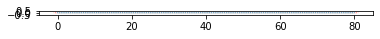

In [6]:
def onsite(site, x0, x1, W0, U0, V):
    (x,) = site.pos
    if x >= x0 - W0/2 and x <= x0 + W0/2 or x >= x1 - W0/2 and x <= x1 + W0/2:
        return 2*t + U0 - x * V/L_nm
    else:
        return 2*t - x * V/L_nm
    
def onsite_lead(site, V):
    (x,) = site.pos
    return 2*t - V

for i in range(N):
    sys[lat(i)] = onsite
    
sys[lat.neighbors()] = -t

leadl = kwant.Builder(kwant.TranslationalSymmetry((-a_nm,)))
leadl[lat(0)] = 2*t
leadl[lat.neighbors()] = -t

leadr = kwant.Builder(kwant.TranslationalSymmetry((a_nm,)))
leadr[lat(0)] = onsite_lead
leadr[lat.neighbors()] = -t

sys.attach_lead(leadl)
sys.attach_lead(leadr)

kwant.plot(sys);

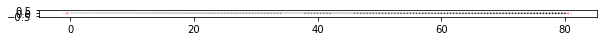

In [7]:
sysf = sys.finalized()
U0p = 0.35
x0p = 36
x1p = 44
W0p = 3
Vp = 1.0
kwant.plot(sysf, site_color=lambda \
           site:sysf.hamiltonian(site, site,params=dict(U0=U0p,x0=x0p, x1=x1p,W0=W0p,V=Vp)),\
           fig_size=(10,10), colorbar=False);

In [8]:
def calc_T(sysf, E, U0, x0, x1, W0, V):
    smatrix = kwant.smatrix(sysf, E, params=dict(U0=U0,x0=x0,x1=x1,W0=W0,V=V))
    return smatrix.transmission(1, 0)

In [9]:
Emin = 0.0001
Emax = 2*U0p
NE = 100

U0p = 0.35
x0p = 36
x1p = 44
W0p = 3
Vp = 0.0


U0pp = 0.35
x0pp = 36
x1pp = 44
W0pp = 3
Vpp = 0.1

Etab = np.linspace(Emin, Emax, NE)
Ttab_p = np.zeros(NE)
Ttab_pp = np.zeros(NE)

for i in range(NE):
    Ttab_p[i] = calc_T(sysf, Etab[i], U0p, x0p, x1p, W0p, Vp)
    Ttab_pp[i] = calc_T(sysf, Etab[i], U0pp, x0pp, x1pp, W0pp, Vpp)
    


U0p= 0.35


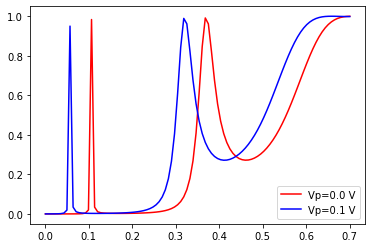

In [10]:
print("U0p=",U0p)
plt.plot(Etab, Ttab_p , "r", label='Vp=0.0 V');
plt.plot(Etab, Ttab_pp , "b", label='Vp=0.1 V');
plt.legend(loc='lower right', ncol=1);

In [11]:
from ipywidgets import interact


def plot_wf(i=1):
    wf = kwant.solvers.default.wave_function(sysf, Etab[i], params=dict(U0=U0p,x0=x0p,x1=x1p,W0=W0p, V=Vp));
    
    print("E=",Etab[i])
    norm=np.sum(np.abs(wf(0)[:])**2)

    
    plt.subplot(1, 2, 1)
    plt.plot((np.abs(wf(0)[0]))**2/norm); 
    plt.xlabel('x')
    plt.ylabel('$|\Psi|^2$')
    plt.grid()
    
    plt.subplot(1, 2, 2)
    plt.plot(Etab,Ttab_p)
    plt.xlabel('E')
    plt.ylabel('T')
    plt.grid()
    plt.axvline(x = Etab[i], color = 'tab:red', label = 'axvline - full height')
    plt.tight_layout()
    plt.show()
       
    
interact(plot_wf, i=(0,NE));

interactive(children=(IntSlider(value=1, description='i'), Output()), _dom_classes=('widget-interact',))

In [12]:
T = 293
bet = 1/(k_B_eV*T)
C = el_charge*m_ef*k_B_eV*T/( 2*np.pi**2*h_bar_eV**3 )*6.242*10**14

def fs_funk(ene, mul, mur, bet):
    return np.log( ( np.exp(-bet*(ene-mul))+1 )/( np.exp(-bet*(ene-mur))+1 ) )

In [13]:
# defining the final system parameters
U0p = 0.35
x0p = 36
x1p = 44
W0p = 3
mu =0.05  #Fermi energy

# defining the range of energies over which we integrate
Emin = 0.0001
Emax = 0.16
NE = 100
Etab = np.linspace(Emin, Emax, NE)
dE = Etab[1] - Etab[0]


# defining the range of voltages which we want to consider
NV = 50
Vmin = 0.0
Vmax = 0.3
Vtab = np.linspace(Vmin, Vmax, NV)
Itab = np.zeros(NV)


# determining the current for each volateg with the use of the Tsu-Esaki formula (numerical integration for each V)
for j in range(NV):
    Vp = Vtab[j]
    mul = mu
    mur = mu - Vp
    for i in range(NE):
        Ttab_p[i] = calc_T(sysf, Etab[i], U0p, x0p, x1p, W0p, Vp)  
        Itab[j] = Itab[j] + Ttab_p[i] * fs_funk(Etab[i], mul, mur, bet) * dE
    
    Itab[j] = C * Itab[j]
    print("Vp=", Vp, " I=", Itab[j])
    


Vp= 0.0  I= 0.0
Vp= 0.006122448979591836  I= 2356.267316796765
Vp= 0.012244897959183673  I= 4769.671592097369
Vp= 0.01836734693877551  I= 7168.195473393571
Vp= 0.024489795918367346  I= 9515.677206576891
Vp= 0.030612244897959183  I= 11881.920136136161
Vp= 0.03673469387755102  I= 14420.432522601792
Vp= 0.04285714285714286  I= 17282.69501481647
Vp= 0.04897959183673469  I= 20521.694263487952
Vp= 0.055102040816326525  I= 24029.569610644656
Vp= 0.061224489795918366  I= 27561.382769594198
Vp= 0.0673469387755102  I= 30927.696720636184
Vp= 0.07346938775510203  I= 34172.74692746601
Vp= 0.07959183673469387  I= 37598.28121132071
Vp= 0.08571428571428572  I= 41605.87775735818
Vp= 0.09183673469387754  I= 46475.68095508975
Vp= 0.09795918367346938  I= 52172.155124440025
Vp= 0.10408163265306122  I= 58261.39710197074
Vp= 0.11020408163265305  I= 64117.090485048335
Vp= 0.11632653061224489  I= 69430.7775117898
Vp= 0.12244897959183673  I= 74572.40012087206
Vp= 0.12857142857142856  I= 80382.27047344201
Vp= 0.

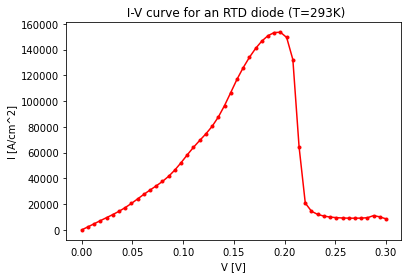

In [14]:
plt.plot(Vtab, Itab, 'r.-');
plt. xlabel("V [V]");
plt. ylabel("I [A/cm^2]");
plt.title(" I-V curve for an RTD diode (T=293K)");